In [24]:
import time
import torch
import random
import os

from glob import glob
from typing import Iterable
import numpy as np
from scipy.io import loadmat
import seaborn as sns
from sklearn.decomposition import PCA

from torch import nn, Tensor, optim
from torch.utils.data import Dataset, DataLoader

# flow_matching
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath, CondOTProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
# To avoide meshgrid warning
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [3]:
if torch.cuda.is_available():
    device = 'cuda:0'
    print('Using gpu')
else:
    device = 'cpu'
    print('Using cpu.')

Using cpu.


In [4]:
torch.manual_seed(42)

In [5]:
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x


# Model class
class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
            )
    

    def forward(self, x: Tensor, t: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()

        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t], dim=1)
        output = self.main(h)
        
        return output.reshape(*sz)

In [6]:
class PoissonDataset(Dataset):
    def __init__(self, data_path, normalize=True, n_samples_for_stats=None):
        
        data = loadmat(data_path)
        self.phi = data["phi_data"]  # Solution (u)
        self.f   = data["f_data"]    # Source term (f)
        self.N   = self.phi.shape[0]
        self.normalize = normalize

        # Compute stats automatically
        if normalize:
            self.stats = self._compute_stats(n_samples_for_stats)
        else:
            self.stats = None

    def _compute_stats(self, n_samples_for_stats):
        """Compute mean/std of u and f across dataset (or a subset)."""
        n = self.N if n_samples_for_stats is None else min(self.N, n_samples_for_stats)
        u_all, f_all = [], []
        for i in range(n):
            u = torch.tensor(self.phi[i], dtype=torch.float32).flatten()
            f = torch.tensor(self.f[i], dtype=torch.float32).flatten()
            u_all.append(u)
            f_all.append(f)
        u_all = torch.cat(u_all)
        f_all = torch.cat(f_all)
        return {
            "u_mean": u_all.mean().item(),
            "u_std":  u_all.std().item(),
            "f_mean": f_all.mean().item(),
            "f_std":  f_all.std().item(),
        }

    def __len__(self):
        return self.N

    def __getitem__(self, index):
        u = torch.tensor(self.phi[index], dtype=torch.float32)
        f = torch.tensor(self.f[index], dtype=torch.float32)

        if self.normalize and self.stats is not None:
            u = (u - self.stats["u_mean"]) / self.stats["u_std"]
            f = (f - self.stats["f_mean"]) / self.stats["f_std"]

        return u, f

In [7]:
poisson_train = glob("/Users/sarperyurtseven/Desktop/master/firstyear/PACS/project/NFsforInverseProblems/data/static/poisson/*8*train*")[0]
poisson_val   = glob("/Users/sarperyurtseven/Desktop/master/firstyear/PACS/project/NFsforInverseProblems/data/static/poisson/*8*val*")[0]
poisson_train_dataset = PoissonDataset(data_path = poisson_train)
poisson_val_dataset   = PoissonDataset(data_path = poisson_val)

In [8]:
train_loader = DataLoader(dataset=poisson_train_dataset, 
                          batch_size=512,
                          shuffle=True)
val_loader = DataLoader(dataset=poisson_val_dataset, 
                          batch_size=512,
                          shuffle=True)

In [9]:
print("Train samples:", len(poisson_train_dataset))
print("Val samples:", len(poisson_val_dataset))

u, f = poisson_train_dataset[0]
print("u shape:", u.shape)
print("f shape:", f.shape)
print("u dtype:", u.dtype)
print("f dtype:", f.dtype)

Train samples: 10000
Val samples: 2000
u shape: torch.Size([8, 8])
f shape: torch.Size([8, 8])
u dtype: torch.float32
f dtype: torch.float32


In [10]:
def describe_tensor(tensor):
    return {
        "min": tensor.min().item(),
        "max": tensor.max().item(),
        "mean": tensor.mean().item(),
        "std": tensor.std().item()
    }

u_stats = describe_tensor(u)
f_stats = describe_tensor(f)
print("u stats:", u_stats)
print("f stats:", f_stats)


u stats: {'min': -6.668127059936523, 'max': 3.0605127811431885, 'mean': -0.7370151877403259, 'std': 2.379133939743042}
f stats: {'min': -3.5029382705688477, 'max': 6.528055667877197, 'mean': -1.4901161193847656e-08, 'std': 2.548494815826416}


In [11]:
def dataset_stats(dataset, n_samples=100):
    u_means, f_means = [], []
    for i in range(min(len(dataset), n_samples)):
        u, f = dataset[i]
        u_means.append(u.mean().item())
        f_means.append(f.mean().item())
    print("u mean mean:", sum(u_means)/len(u_means))
    print("f mean mean:", sum(f_means)/len(f_means))

dataset_stats(poisson_train_dataset)


u mean mean: 0.042873106142506
f mean mean: -3.4924596548080444e-10


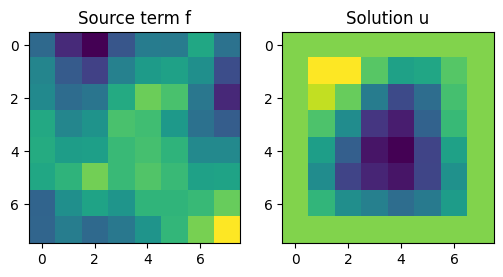

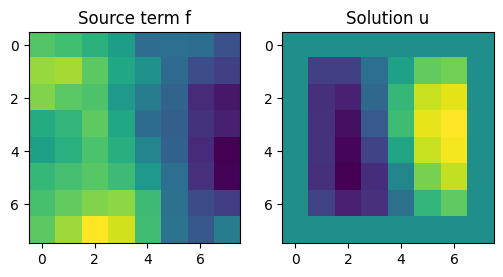

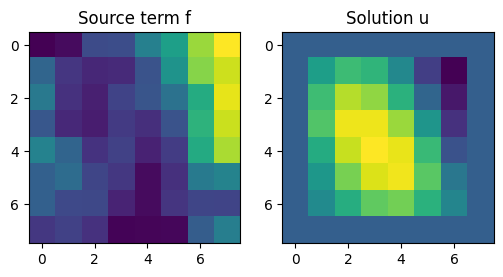

In [12]:
for i in random.sample(range(len(poisson_train_dataset)), 3):
    u, f = poisson_train_dataset[i]
    fig, ax = plt.subplots(1, 2, figsize=(6,3))
    ax[0].imshow(f, cmap='viridis'); ax[0].set_title("Source term f")
    ax[1].imshow(u, cmap='viridis'); ax[1].set_title("Solution u")
    plt.show()

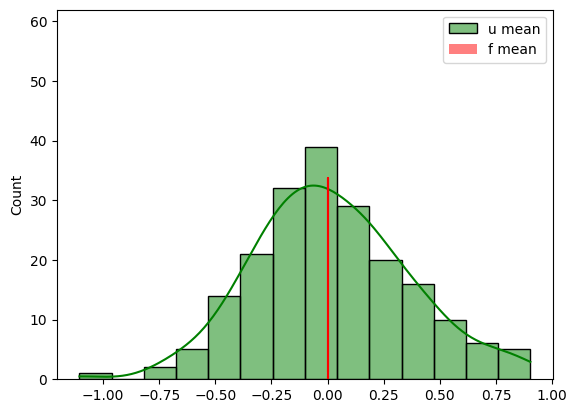

In [13]:
us, fs = [], []
for i in range(200):  # sample subset
    u, f = poisson_train_dataset[i]
    us.append(u.mean().item())
    fs.append(f.mean().item())

sns.histplot(us, kde=True, color='green', label='u mean')
sns.histplot(fs, kde=True, color='red', label='f mean')
plt.legend(); plt.show()

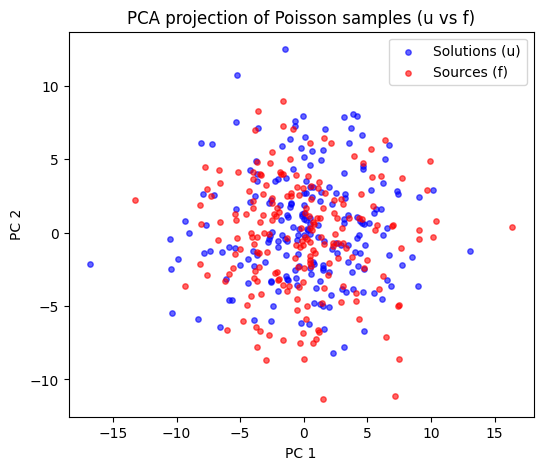

In [14]:
# Collect samples
U, F = [], []
n_samples = min(200, len(poisson_train_dataset))

for i in range(n_samples):
    u, f = poisson_train_dataset[i]
    U.append(u.flatten())
    F.append(f.flatten())

U = np.stack(U)
F = np.stack(F)

# --- Fit PCA on combined data ---
X = np.concatenate([U, F], axis=0)
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

# Split back
u_2d = X_2d[:len(U)]
f_2d = X_2d[len(U):]

# --- Plot together ---
plt.figure(figsize=(6,5))
plt.scatter(u_2d[:,0], u_2d[:,1], s=15, color='blue', alpha=0.6, label='Solutions (u)')
plt.scatter(f_2d[:,0], f_2d[:,1], s=15, color='red', alpha=0.6, label='Sources (f)')
plt.legend()
plt.title("PCA projection of Poisson samples (u vs f)")
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.show()


In [26]:
def train(
    model: nn.Module, 
    data_loader: Iterable, 
    optimizer: optim.Optimizer, 
    lr_schedule: optim.lr_scheduler.LRScheduler, 
    device: torch.device,
    epochs: int,
    max_grad_norm: float = 1.0,
    save_interval: int = 20000,
    save_dir: str = "checkpoints"
):
    for epoch in range(epochs):
        start_time = time.time()
        train_loss = train_one_epoch(
            model=model,
            data_loader=data_loader,
            optimizer=optimizer,
            lr_schedule=lr_schedule,
            device=device,
            epoch=epoch,
            max_grad_norm=max_grad_norm
        )

        lr_schedule.step()
        elapsed = time.time() - start_time
        
        if epoch % 300 == 0 or epoch == epochs - 1:
            current_lr = optimizer.param_groups[0]['lr']
            print(
                f"[Epoch {epoch+1:04d}/{epochs}] "
                f"Train Loss: {train_loss:.10f} | "
                f"LR: {current_lr:.2e} | "
                f"Time: {elapsed:.2f}s"
            )

        if (epoch % save_interval == 0 and epoch != 0) or epoch == epochs - 1:
            ckpt_path = os.path.join(save_dir, f"poisson_flowmatching_epoch_{epoch+1}.pt")
            torch.save({
                "epoch": epoch + 1,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": lr_schedule.state_dict(),
                "train_loss": train_loss,
            }, ckpt_path)

            vis_dir = os.path.join(save_dir, "visualizations")
            os.makedirs(vis_dir, exist_ok=True)
            fig_path = os.path.join(vis_dir, f"poisson_flowmatching_epoch_{epoch+1:05d}.png")
            visualize_flow_evolution(model, val_loader, n_steps=8, device=device)
            plt.savefig(fig_path, dpi=200, bbox_inches="tight")
            plt.close()

In [16]:
def train_one_epoch(
    model: nn.Module, 
    data_loader: Iterable, 
    optimizer: optim.Optimizer, 
    lr_schedule: optim.lr_scheduler.LRScheduler, 
    device: torch.device,
    epoch: int,
    max_grad_norm: float = 1.0
):
    model.train()
    train_loss = 0.0
    path = CondOTProbPath()

    for batch_idx, (u, f) in enumerate(data_loader):
        optimizer.zero_grad()

        u = u.flatten(start_dim=1).float().to(device)
        f = f.flatten(start_dim=1).float().to(device)
        t = torch.rand(f.shape[0], device=device)  
        
        # Sample from conditional path
        path_sample = path.sample(t=t, x_0=f, x_1=u)
        x_t, dx_t = path_sample.x_t, path_sample.dx_t

        # Compute loss
        loss = ((model(x_t, t) - dx_t) ** 2).mean()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(data_loader)
    return train_loss

In [17]:
BATCH_SIZE = 512

In [18]:
poisson_train = glob("/Users/sarperyurtseven/Desktop/master/firstyear/PACS/project/NFsforInverseProblems/data/static/poisson/*16*train*")[0]
poisson_val   = glob("/Users/sarperyurtseven/Desktop/master/firstyear/PACS/project/NFsforInverseProblems/data/static/poisson/*16*val*")[0]

In [19]:
poisson_train_dataset = PoissonDataset(data_path = poisson_train)
poisson_val_dataset   = PoissonDataset(data_path = poisson_val)

In [20]:
train_loader = DataLoader(dataset=poisson_train_dataset, 
                          batch_size=BATCH_SIZE,
                          shuffle=True)
val_loader = DataLoader(dataset=poisson_val_dataset, 
                          batch_size=BATCH_SIZE,
                          shuffle=True)

In [21]:
input_size = train_loader.dataset.phi[0].shape[0]

In [22]:
flow = MLP(input_dim=input_size**2, 
            hidden_dim=256)
flow = flow.to(device)
optimizer = torch.optim.Adam(flow.parameters(), 
                       lr=3e-5)
epochs = 100001
loss_fn = nn.MSELoss()
lr_schedule = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=epochs, 
    eta_min=1e-6
)

[Epoch 0001/100001] Train Loss: 0.0341031300 | LR: 1.10e-05 | Time: 0.12s
[Epoch 0301/100001] Train Loss: 0.0337504521 | LR: 1.09e-05 | Time: 0.03s
[Epoch 0601/100001] Train Loss: 0.0335816722 | LR: 1.08e-05 | Time: 0.03s
[Epoch 0901/100001] Train Loss: 0.0334891016 | LR: 1.06e-05 | Time: 0.03s
[Epoch 1201/100001] Train Loss: 0.0340610752 | LR: 1.05e-05 | Time: 0.03s
[Epoch 1501/100001] Train Loss: 0.0338450437 | LR: 1.04e-05 | Time: 0.03s
[Epoch 1801/100001] Train Loss: 0.0342890192 | LR: 1.02e-05 | Time: 0.03s
[Epoch 2101/100001] Train Loss: 0.0338064851 | LR: 1.01e-05 | Time: 0.03s
[Epoch 2401/100001] Train Loss: 0.0341244098 | LR: 9.99e-06 | Time: 0.03s
[Epoch 2701/100001] Train Loss: 0.0336519117 | LR: 9.87e-06 | Time: 0.03s
[Epoch 3001/100001] Train Loss: 0.0334921209 | LR: 9.74e-06 | Time: 0.03s
[Epoch 3301/100001] Train Loss: 0.0334126987 | LR: 9.61e-06 | Time: 0.03s
[Epoch 3601/100001] Train Loss: 0.0332571575 | LR: 9.49e-06 | Time: 0.03s
[Epoch 3901/100001] Train Loss: 0.0337

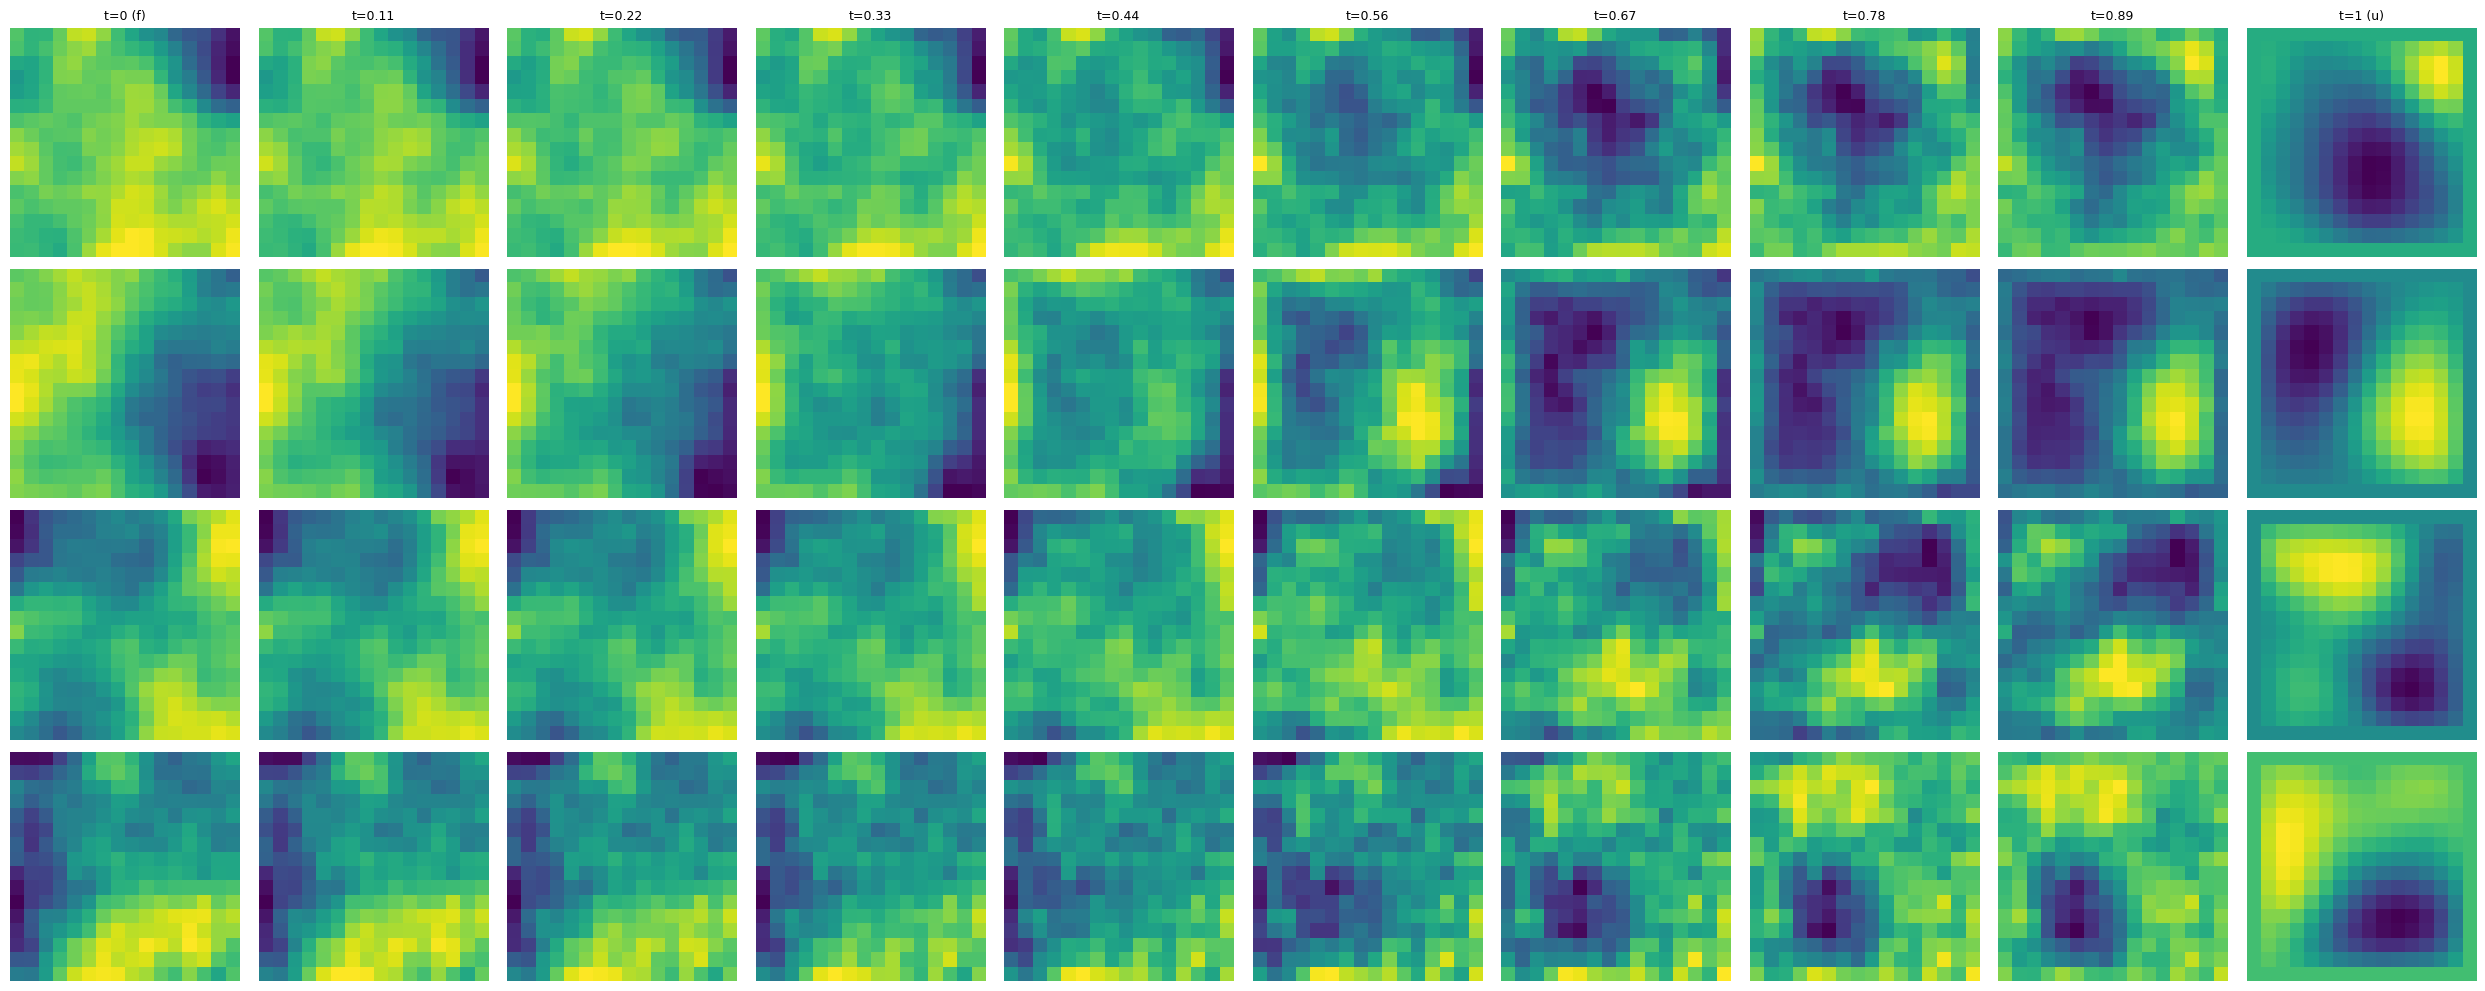

[Epoch 20101/100001] Train Loss: 0.0314031662 | LR: 3.74e-06 | Time: 0.03s
[Epoch 20401/100001] Train Loss: 0.0319685927 | LR: 3.66e-06 | Time: 0.03s
[Epoch 20701/100001] Train Loss: 0.0318726231 | LR: 3.58e-06 | Time: 0.04s
[Epoch 21001/100001] Train Loss: 0.0317828651 | LR: 3.51e-06 | Time: 0.03s
[Epoch 21301/100001] Train Loss: 0.0317029953 | LR: 3.43e-06 | Time: 0.03s
[Epoch 21601/100001] Train Loss: 0.0313042738 | LR: 3.36e-06 | Time: 0.03s
[Epoch 21901/100001] Train Loss: 0.0312958225 | LR: 3.28e-06 | Time: 0.03s
[Epoch 22201/100001] Train Loss: 0.0314313937 | LR: 3.21e-06 | Time: 0.03s
[Epoch 22501/100001] Train Loss: 0.0310984082 | LR: 3.14e-06 | Time: 0.03s
[Epoch 22801/100001] Train Loss: 0.0317537077 | LR: 3.07e-06 | Time: 0.03s
[Epoch 23101/100001] Train Loss: 0.0313247032 | LR: 3.00e-06 | Time: 0.03s
[Epoch 23401/100001] Train Loss: 0.0315151201 | LR: 2.93e-06 | Time: 0.03s
[Epoch 23701/100001] Train Loss: 0.0309068472 | LR: 2.86e-06 | Time: 0.04s
[Epoch 24001/100001] Trai

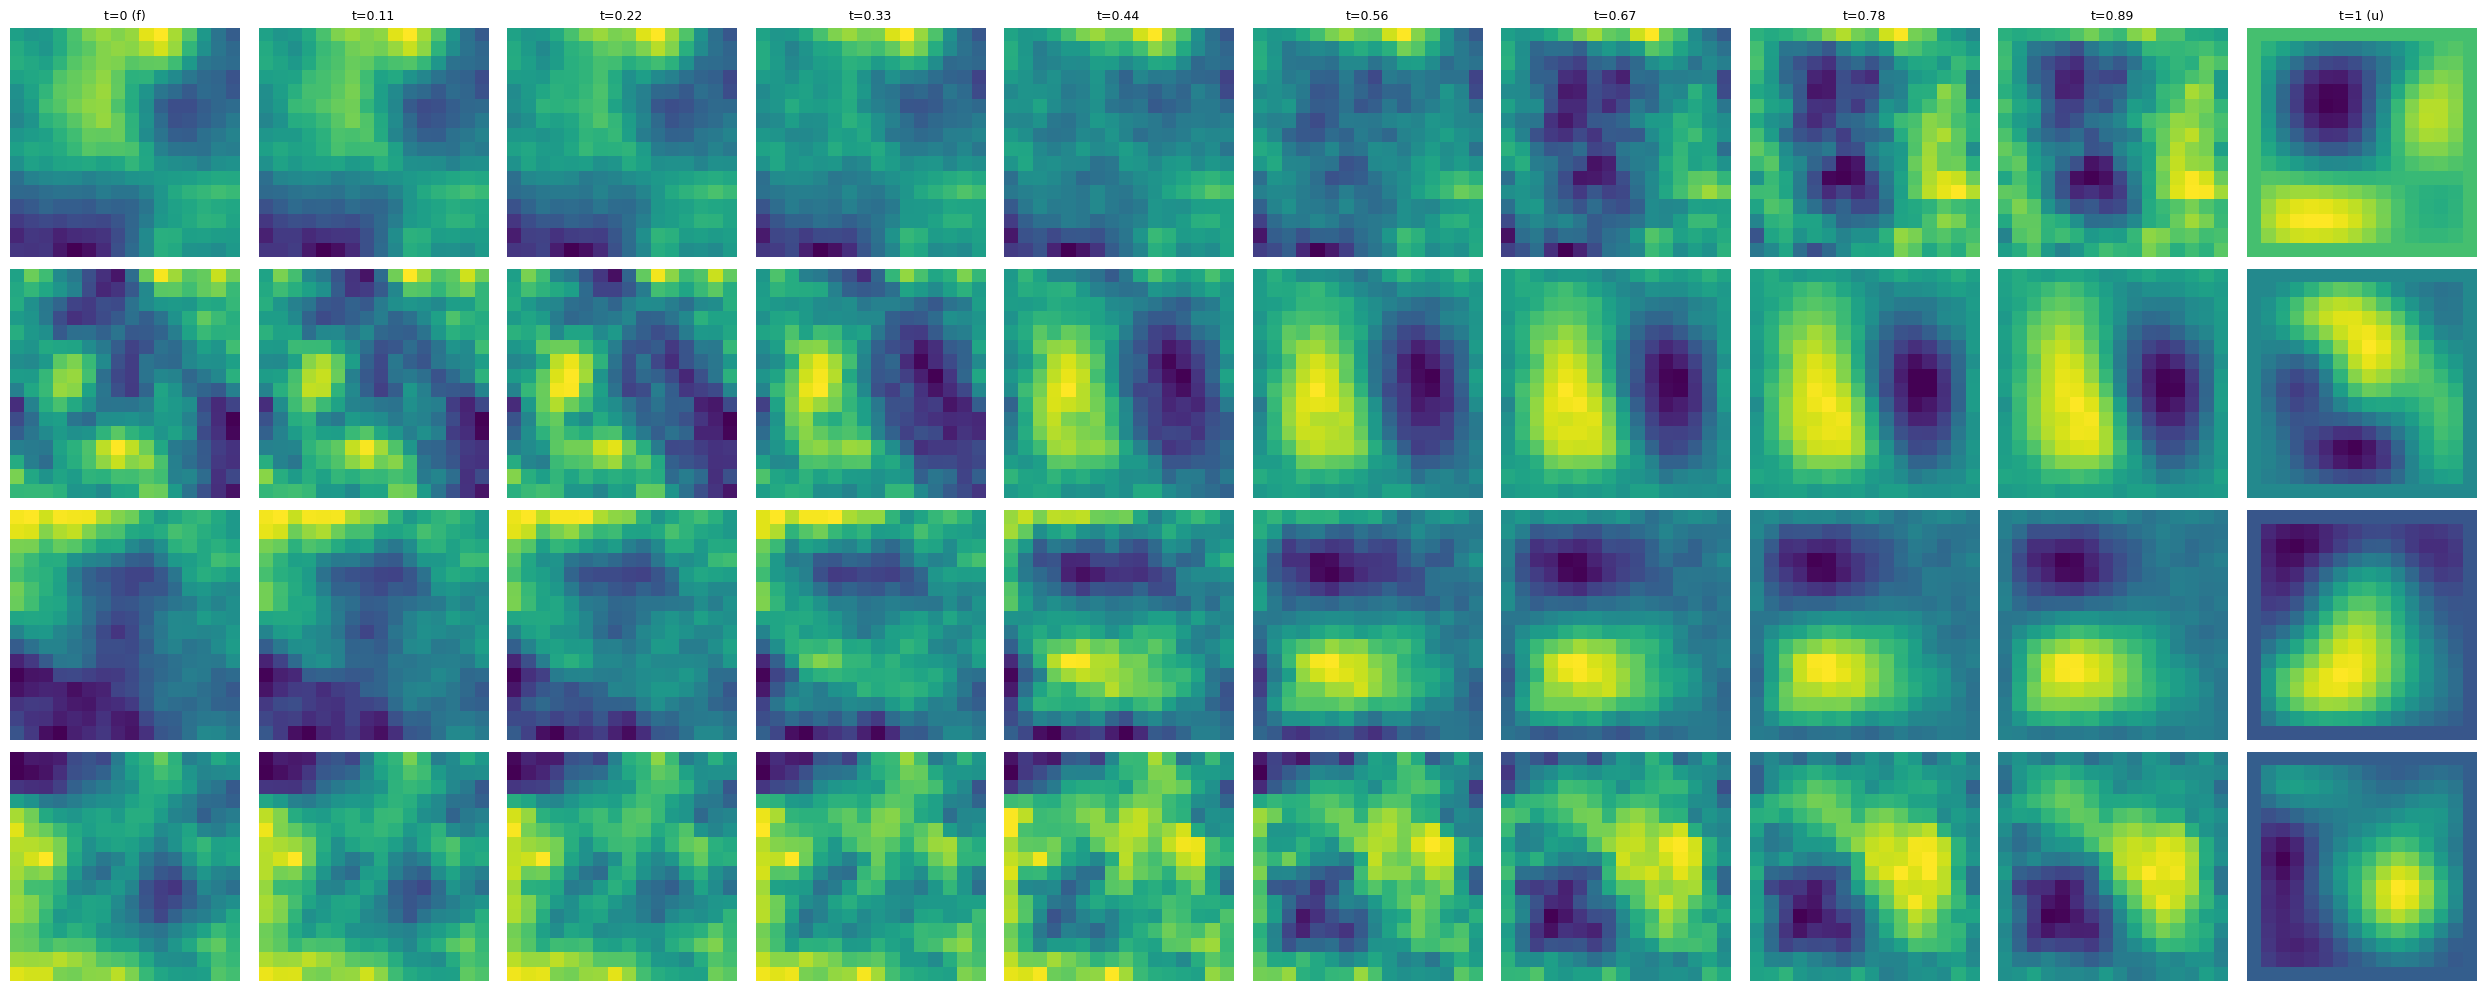

[Epoch 40201/100001] Train Loss: 0.0308840005 | LR: 1.00e-06 | Time: 0.03s
[Epoch 40501/100001] Train Loss: 0.0309680942 | LR: 1.00e-06 | Time: 0.03s
[Epoch 40801/100001] Train Loss: 0.0307496418 | LR: 1.00e-06 | Time: 0.03s
[Epoch 41101/100001] Train Loss: 0.0306847794 | LR: 1.01e-06 | Time: 0.03s
[Epoch 41401/100001] Train Loss: 0.0307535673 | LR: 1.01e-06 | Time: 0.05s
[Epoch 41701/100001] Train Loss: 0.0309010898 | LR: 1.02e-06 | Time: 0.05s
[Epoch 42001/100001] Train Loss: 0.0309722293 | LR: 1.03e-06 | Time: 0.03s
[Epoch 42301/100001] Train Loss: 0.0307733752 | LR: 1.04e-06 | Time: 0.03s
[Epoch 42601/100001] Train Loss: 0.0311131575 | LR: 1.05e-06 | Time: 0.03s
[Epoch 42901/100001] Train Loss: 0.0312359394 | LR: 1.06e-06 | Time: 0.03s
[Epoch 43201/100001] Train Loss: 0.0313080172 | LR: 1.07e-06 | Time: 0.03s
[Epoch 43501/100001] Train Loss: 0.0308387908 | LR: 1.09e-06 | Time: 0.03s
[Epoch 43801/100001] Train Loss: 0.0304050506 | LR: 1.10e-06 | Time: 0.03s
[Epoch 44101/100001] Trai

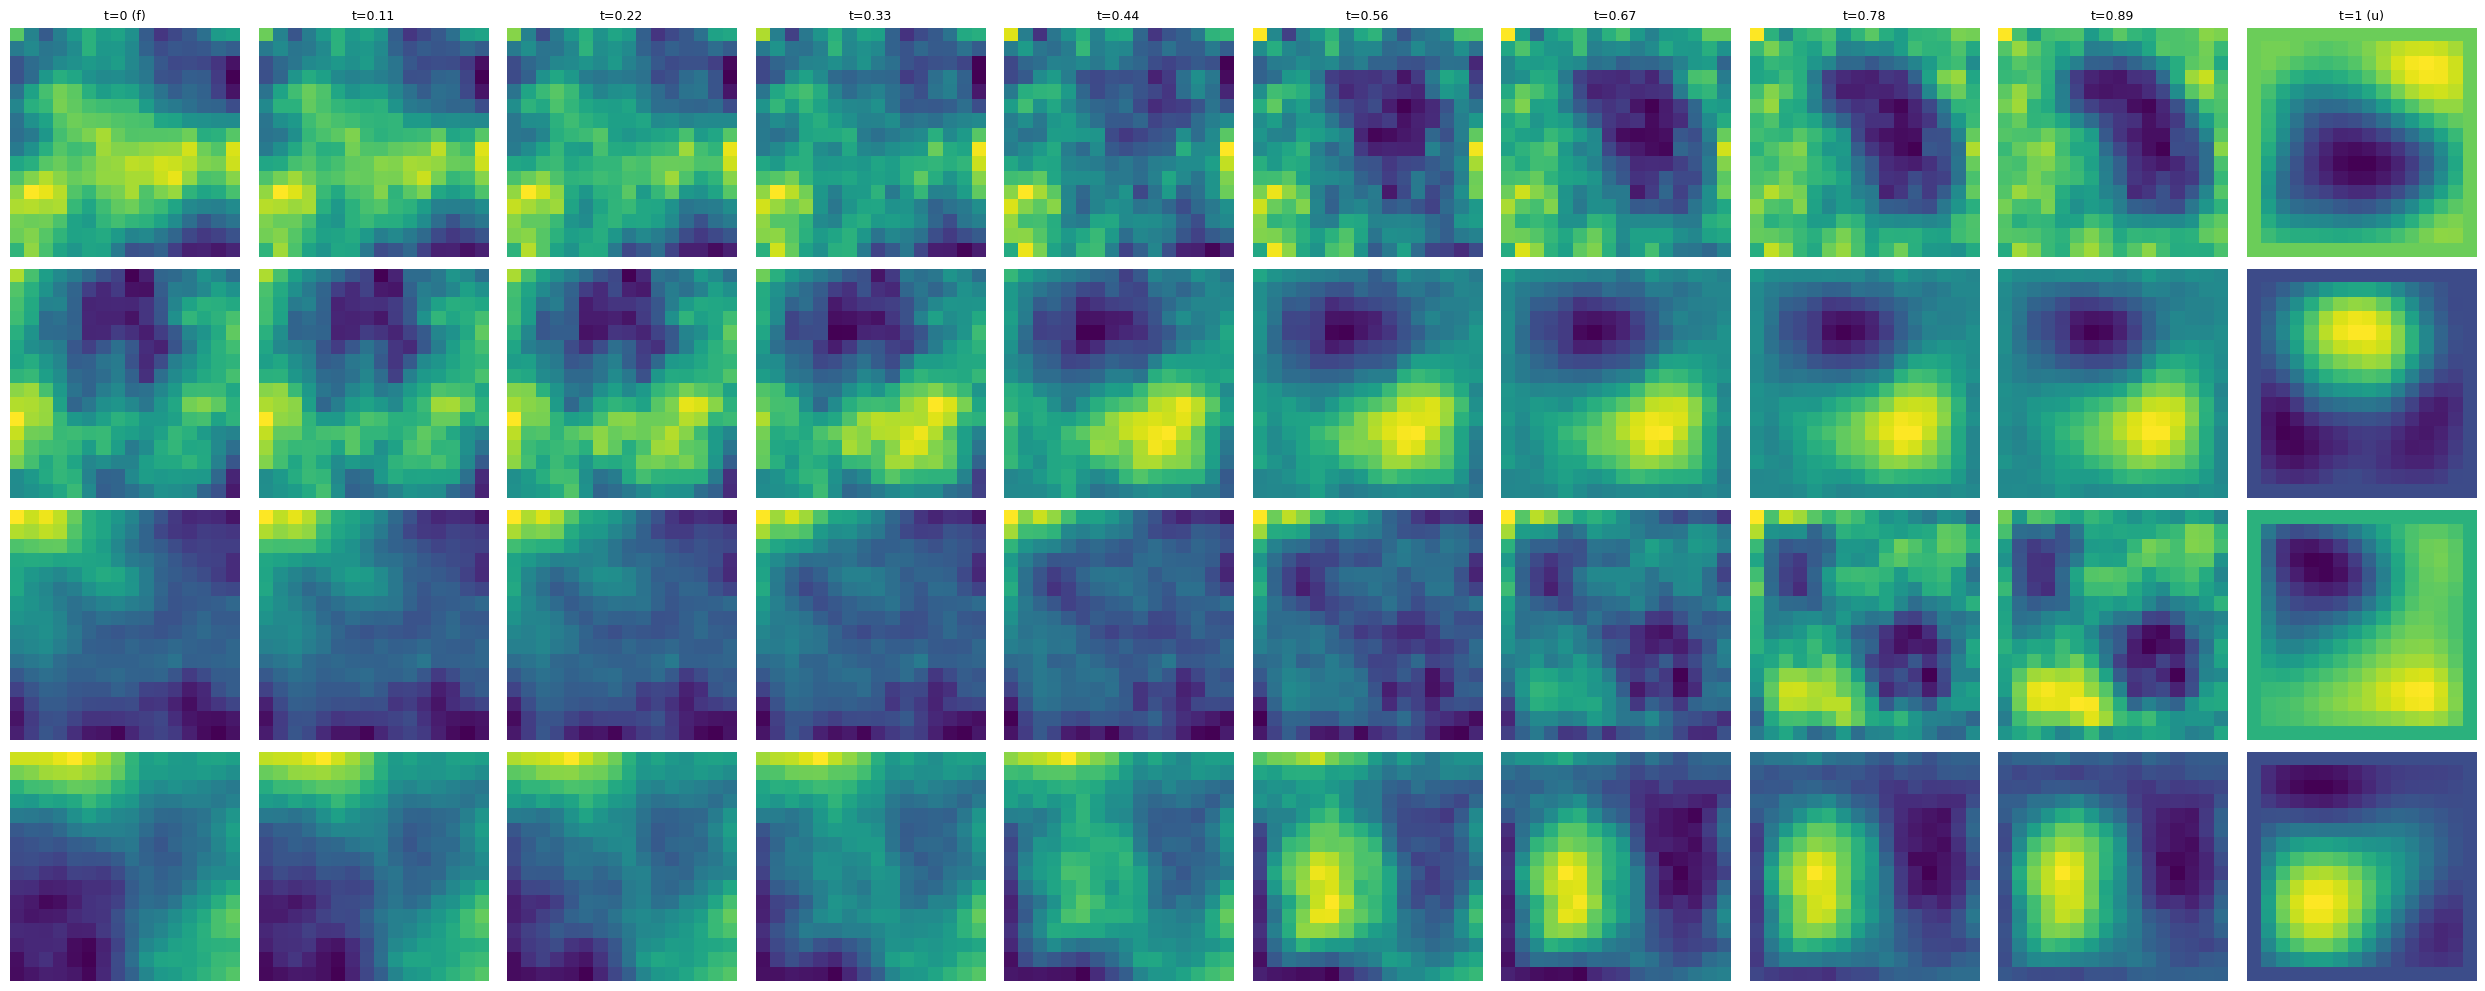

[Epoch 60301/100001] Train Loss: 0.0300842384 | LR: 3.85e-06 | Time: 0.03s
[Epoch 60601/100001] Train Loss: 0.0299076638 | LR: 3.93e-06 | Time: 0.03s
[Epoch 60901/100001] Train Loss: 0.0300976448 | LR: 4.02e-06 | Time: 0.03s
[Epoch 61201/100001] Train Loss: 0.0295283869 | LR: 4.10e-06 | Time: 0.03s
[Epoch 61501/100001] Train Loss: 0.0303012440 | LR: 4.18e-06 | Time: 0.03s
[Epoch 61801/100001] Train Loss: 0.0304555013 | LR: 4.27e-06 | Time: 0.03s
[Epoch 62101/100001] Train Loss: 0.0299192281 | LR: 4.36e-06 | Time: 0.03s
[Epoch 62401/100001] Train Loss: 0.0302822362 | LR: 4.45e-06 | Time: 0.03s
[Epoch 62701/100001] Train Loss: 0.0300320275 | LR: 4.53e-06 | Time: 0.03s
[Epoch 63001/100001] Train Loss: 0.0302104605 | LR: 4.62e-06 | Time: 0.03s
[Epoch 63301/100001] Train Loss: 0.0303371754 | LR: 4.72e-06 | Time: 0.03s
[Epoch 63601/100001] Train Loss: 0.0304122623 | LR: 4.81e-06 | Time: 0.03s
[Epoch 63901/100001] Train Loss: 0.0301199774 | LR: 4.90e-06 | Time: 0.03s
[Epoch 64201/100001] Trai

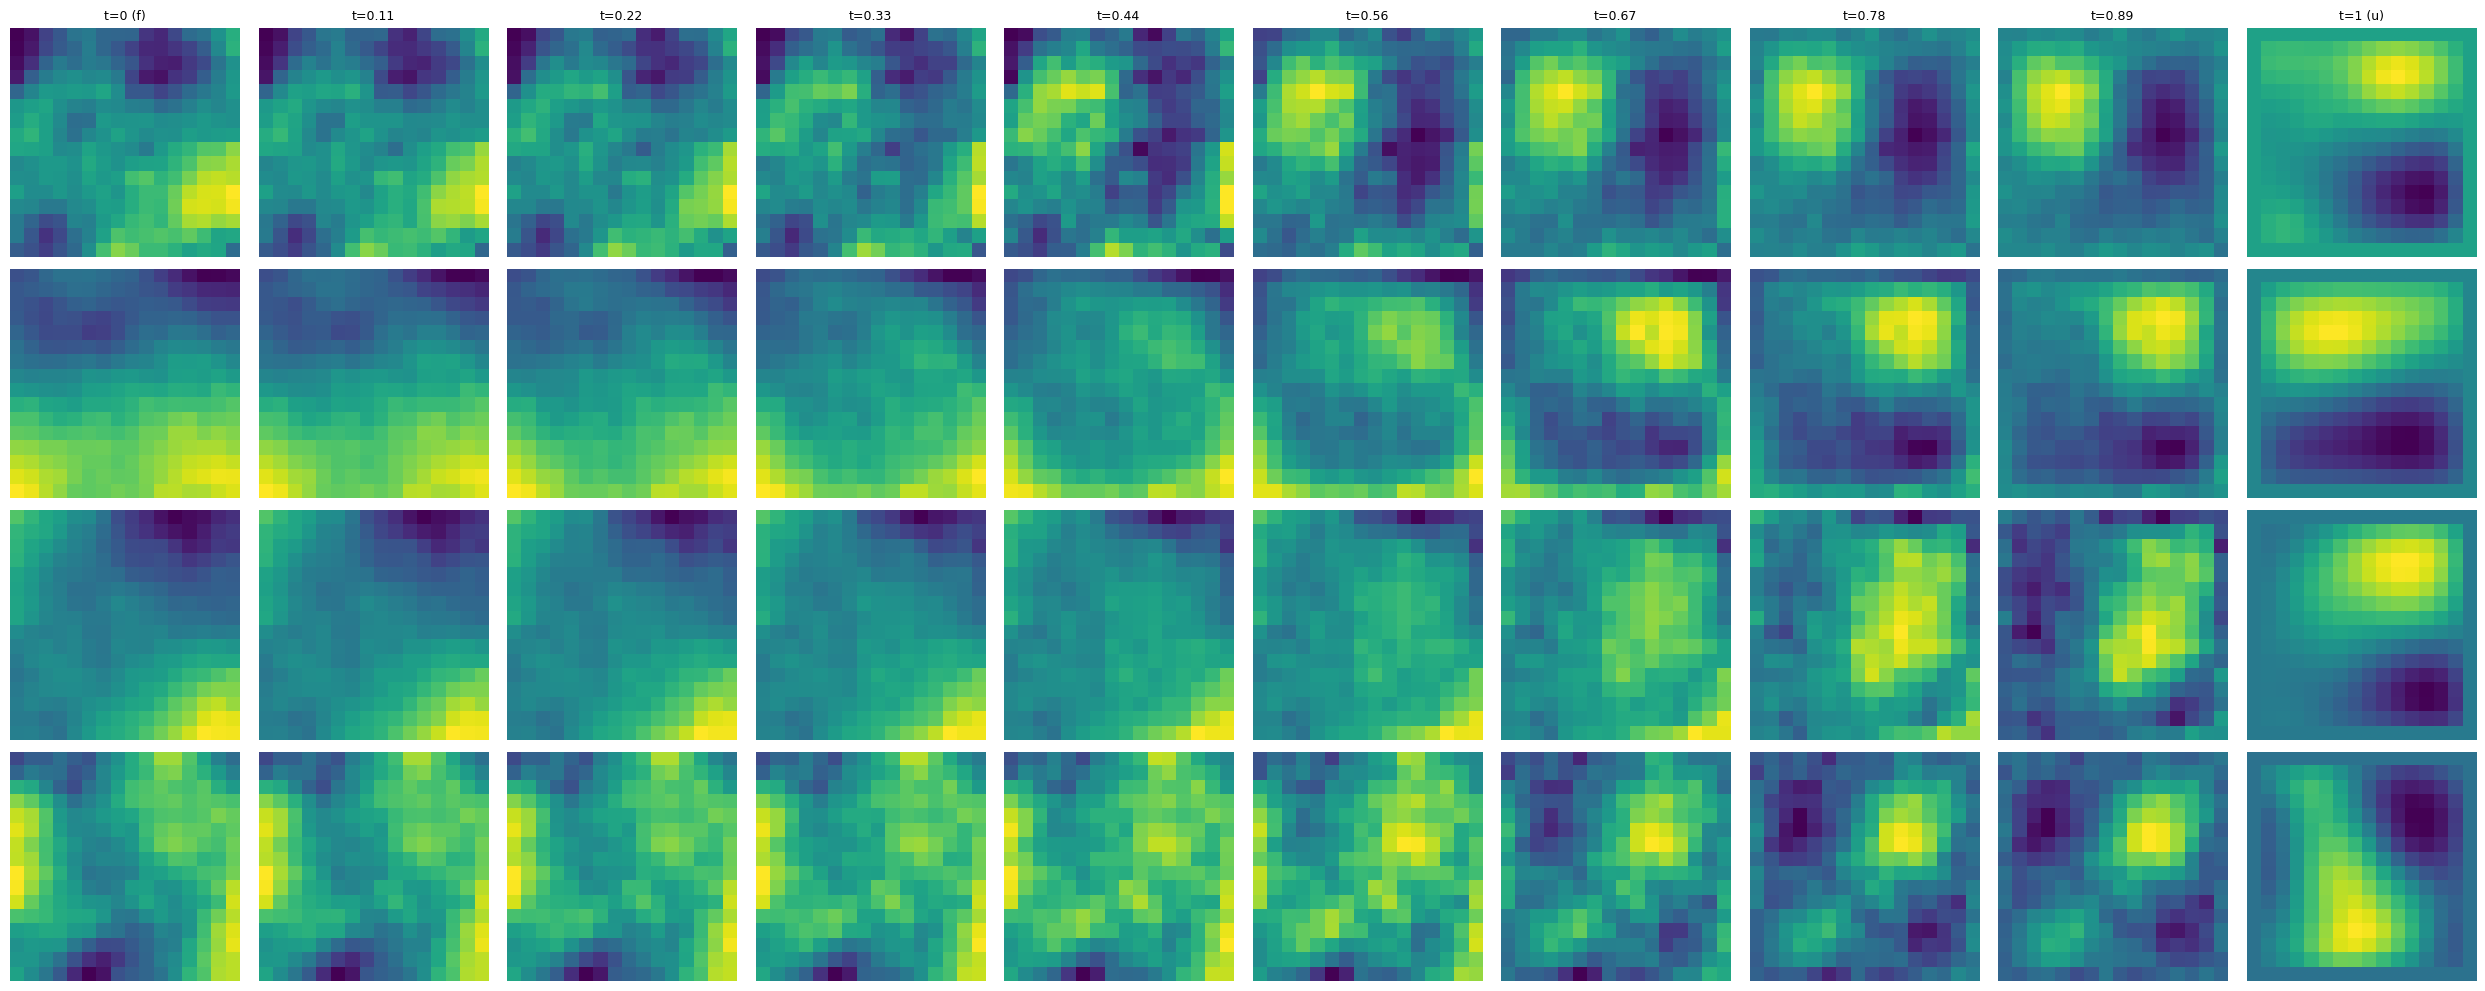

[Epoch 80101/100001] Train Loss: 0.0289547928 | LR: 1.11e-05 | Time: 0.03s
[Epoch 80401/100001] Train Loss: 0.0286011216 | LR: 1.12e-05 | Time: 0.03s
[Epoch 80701/100001] Train Loss: 0.0281556509 | LR: 1.13e-05 | Time: 0.03s
[Epoch 81001/100001] Train Loss: 0.0279849381 | LR: 1.15e-05 | Time: 0.03s
[Epoch 81301/100001] Train Loss: 0.0286458777 | LR: 1.16e-05 | Time: 0.03s
[Epoch 81601/100001] Train Loss: 0.0282675363 | LR: 1.17e-05 | Time: 0.03s
[Epoch 81901/100001] Train Loss: 0.0283070877 | LR: 1.19e-05 | Time: 0.03s
[Epoch 82201/100001] Train Loss: 0.0282519409 | LR: 1.20e-05 | Time: 0.03s
[Epoch 82501/100001] Train Loss: 0.0284709674 | LR: 1.21e-05 | Time: 0.03s
[Epoch 82801/100001] Train Loss: 0.0283113737 | LR: 1.22e-05 | Time: 0.03s
[Epoch 83101/100001] Train Loss: 0.0277277427 | LR: 1.24e-05 | Time: 0.04s
[Epoch 83401/100001] Train Loss: 0.0279865381 | LR: 1.25e-05 | Time: 0.04s
[Epoch 83701/100001] Train Loss: 0.0275469772 | LR: 1.26e-05 | Time: 0.04s
[Epoch 84001/100001] Trai

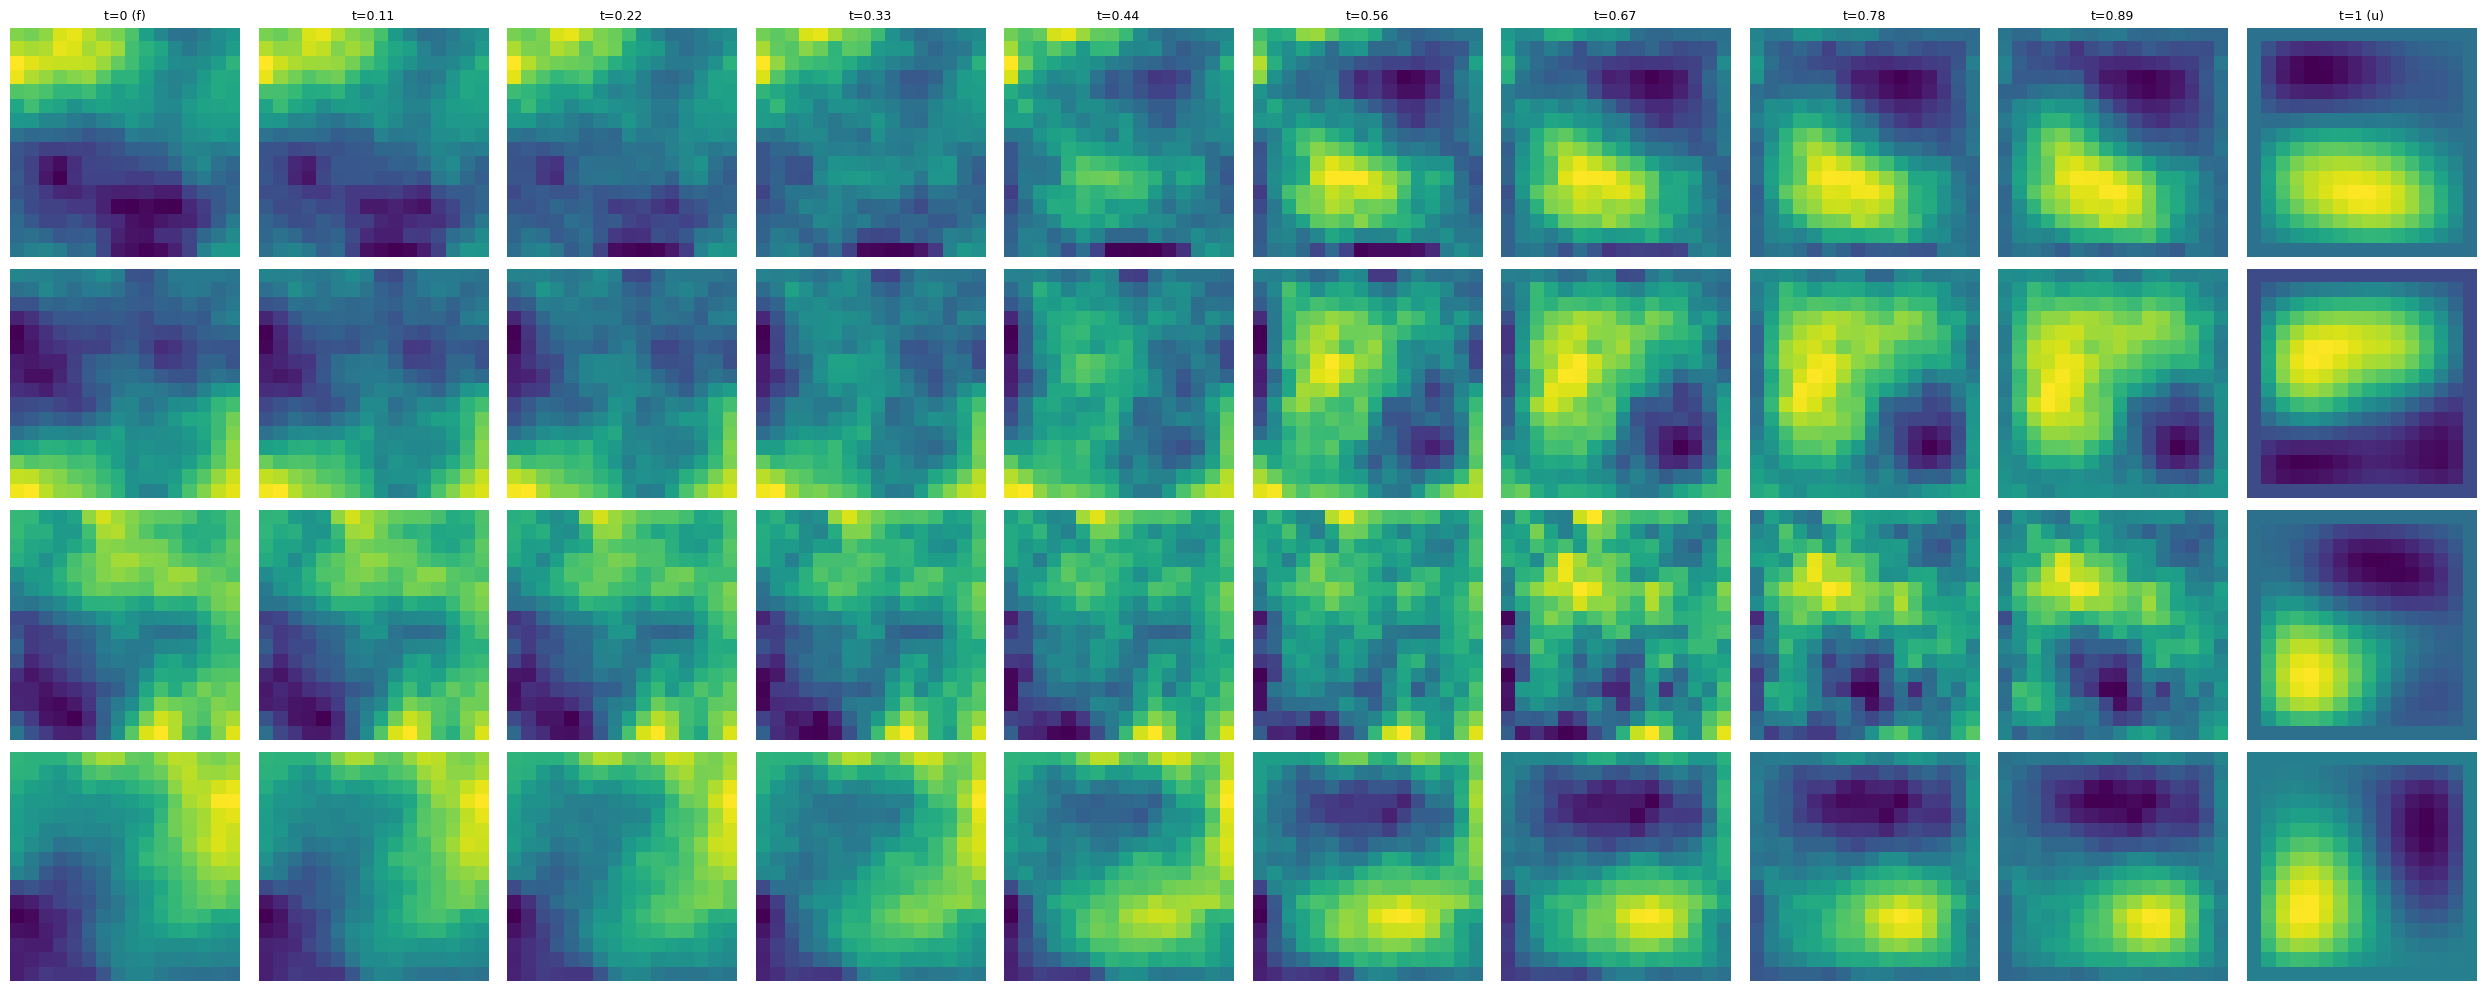

In [30]:
train(
    model=flow,
    data_loader=train_loader,
    optimizer=optimizer,
    lr_schedule=lr_schedule,
    device=device,
    epochs=epochs,
)

In [31]:
@torch.no_grad()
def visualize_flow_evolution(model, val_loader, n_steps=10, device='cuda'):
    model.eval()
    path = CondOTProbPath()

    # --- Get a small batch from validation set ---
    u, f = next(iter(val_loader))
    u = u.flatten(start_dim=1).float().to(device)
    f = f.flatten(start_dim=1).float().to(device)

    n_samples = min(4, f.shape[0])       # how many samples to visualize
    dim = f.shape[1]
    H = W = int(dim**0.5)                # assume square grid (e.g., 64x64)
    t_vals = torch.linspace(0, 1, n_steps + 2, device=device)

    fig, axes = plt.subplots(n_samples, len(t_vals), figsize=(2.5*len(t_vals), 2.5*n_samples))
    if n_samples == 1:
        axes = axes.unsqueeze(0)

    # --- Evolve each sample ---
    for i in range(n_samples):
        x_t = f[i].unsqueeze(0)  # start from x0 = f

        for j, t in enumerate(t_vals):
            if j == 0:
                x_plot = f[i]
                title = "t=0 (f)"
            elif j == len(t_vals) - 1:
                x_plot = u[i]
                title = "t=1 (u)"
            else:
                # One Euler step: x_{t+dt} = x_t + dt * v(x_t, t)
                dt = t_vals[j] - t_vals[j-1]
                t_mid = (t_vals[j] + t_vals[j-1]) / 2
                v_t = model(x_t, t_mid.repeat(x_t.size(0), 1))
                x_t = x_t + dt * v_t
                x_plot = x_t.squeeze(0)
                title = f"t={t.item():.2f}"

            ax = axes[i, j]
            ax.imshow(x_plot.view(H, W).cpu(), cmap='viridis')
            ax.axis('off')
            if i == 0:
                ax.set_title(title, fontsize=9)

    plt.tight_layout()
    plt.show()


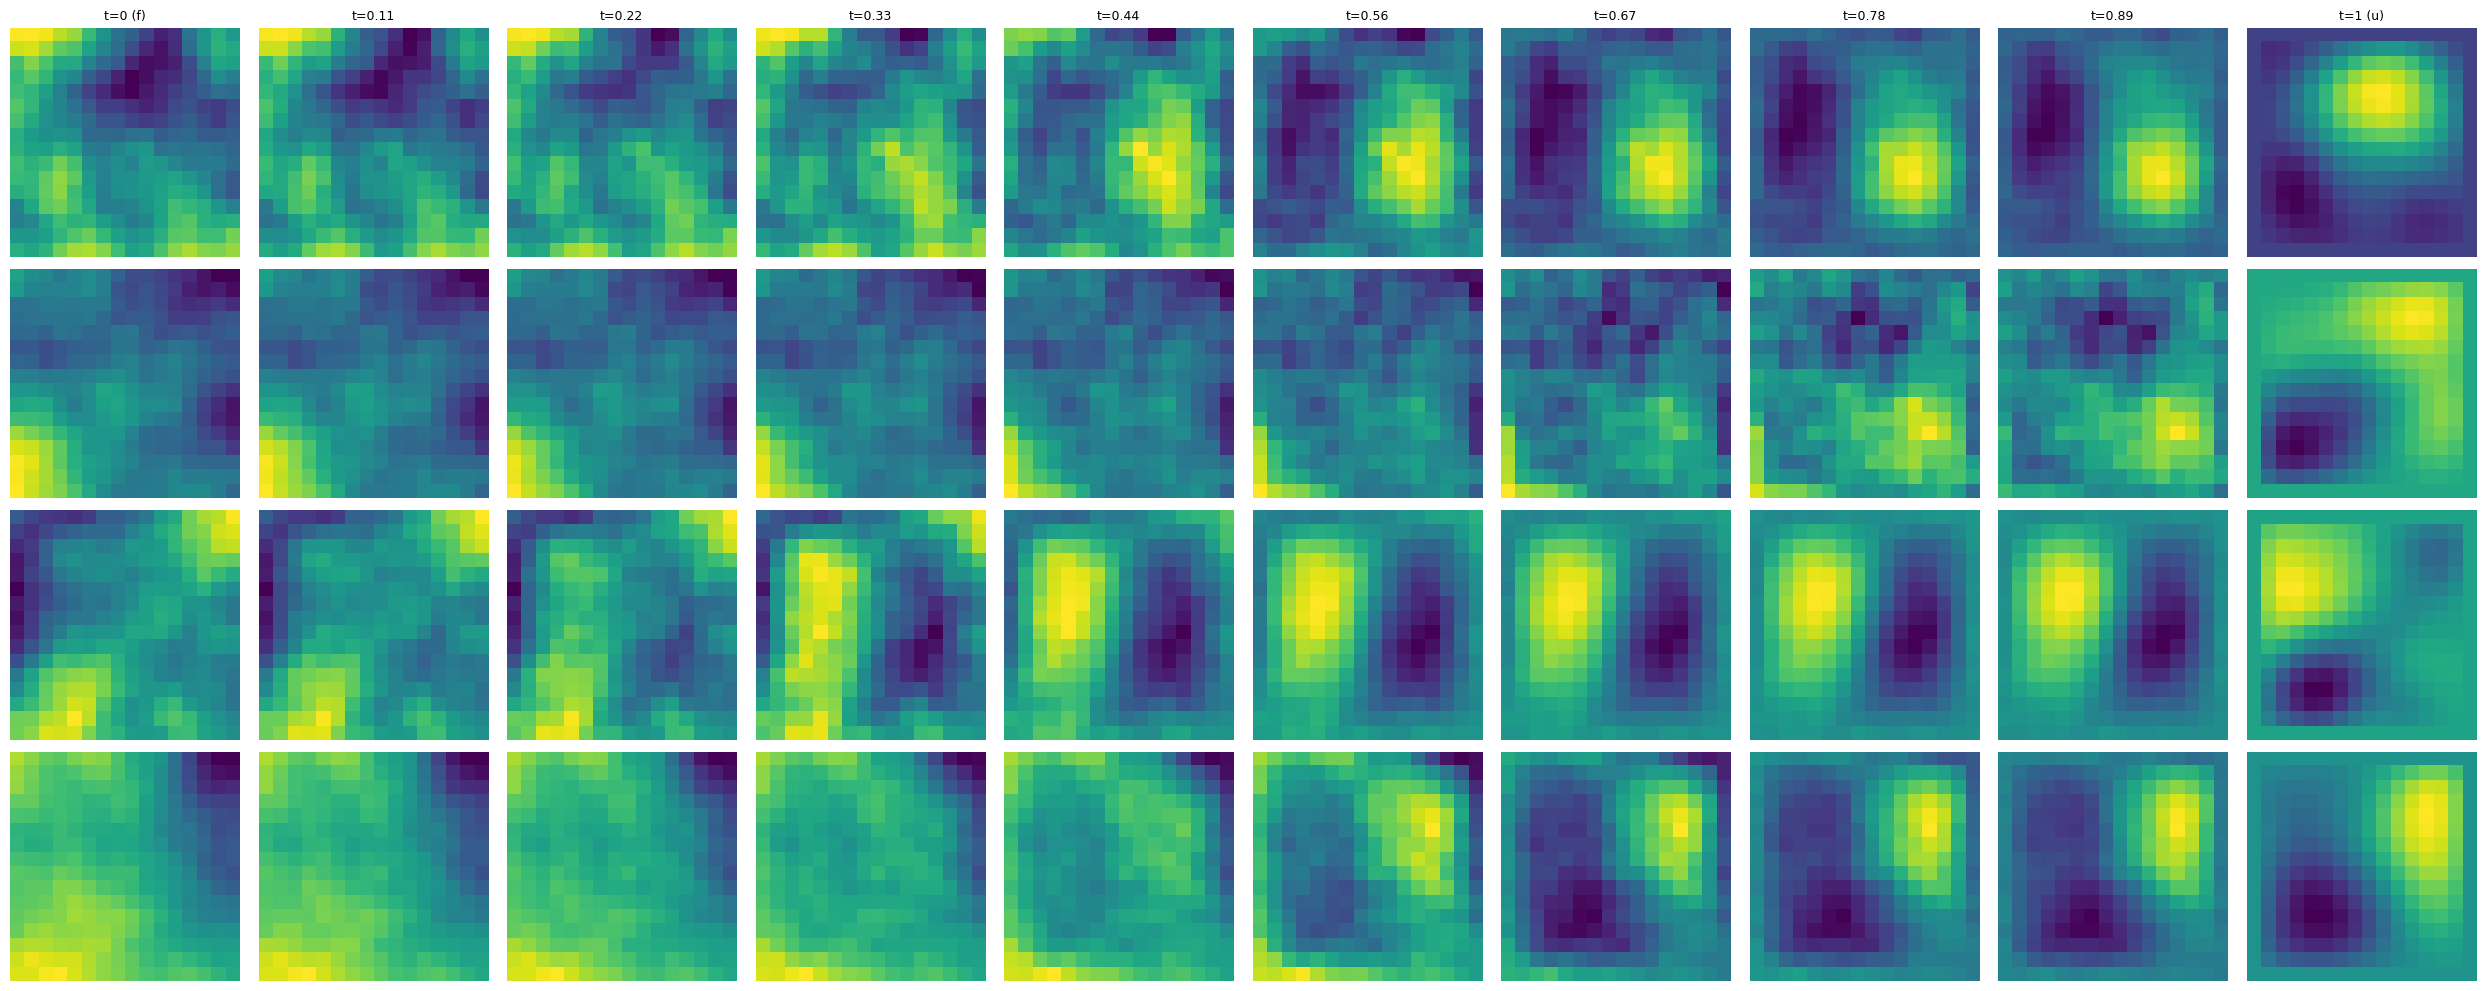

In [35]:
visualize_flow_evolution(flow, val_loader, n_steps=8, device=device)